# libcds StripedMap vs BronsonAVLTreeMap vs Wormhole — lock primitive comparison

Three concurrent indexes, each with a pluggable lock primitive at a different
structural level (StripedMap: per-stripe; BronsonAVL: per-node monitor;
Wormhole: per-leaf rwlock + per-leaf spinlock).

**StripedMap & BronsonAVL** use these primitives:

| Lock     | Description |
|----------|-------------|
| `std`    | `std::mutex` baseline |
| `tas`    | atomic_flag test-and-set spinlock |
| `ttas`   | test-and-test-and-set spinlock |
| `cas`    | CAS-based exchange spinlock |
| `ticket` | strict-FIFO ticket lock |

**Wormhole** uses a different set (ticket excluded — see EXPERIMENT.md):

| Lock      | Description |
|-----------|-------------|
| `default` | Wu's stock rwlock (upstream wormhole, no shim) |
| `rw`      | `rw_lock` — true reader-writer lock |
| `tas`     | exclusive-only via shim |
| `ttas`    | exclusive-only via shim |
| `cas`     | exclusive-only via shim |
| `occ`     | exclusive-only via shim (seqlock-as-mutex) |


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_AVL = Path('../results/avl_compare')
RESULTS_WH  = Path('../results/wh_compare')
cds = pd.read_csv(RESULTS_AVL / 'cds_striped.csv', sep=';', decimal=',')
avl = pd.read_csv(RESULTS_AVL / 'cds_avl.csv',     sep=';', decimal=',')
wh  = pd.read_csv(RESULTS_WH  / 'wh.csv',          sep=';', decimal=',')

cds['lk']  = cds['lock'].str.replace('cds-', '', regex=False)
avl['lk']  = avl['lock'].str.replace('avl-', '', regex=False)
wh['lk']   = wh['lock'].str.replace('wh-',   '', regex=False)
cds['ds']  = 'StripedMap'
avl['ds']  = 'BronsonAVL'
wh['ds']   = 'Wormhole'

def workload(row):
    rd, ins = int(row['read_pct']), int(row['insert_pct'])
    if rd == 80 and ins == 10:  return f"{row['dist']} 80/10/10"
    if rd == 90 and ins == 5:   return 'uniform 90/5/5 read-heavy'
    if rd == 20 and ins == 40:  return 'zipfian 20/40/40 write-heavy'
    return f"{row['dist']} {rd}/{ins}/{100-rd-ins}"
for df in (cds, avl, wh):
    df['workload'] = df.apply(workload, axis=1)

for name, df in [('StripedMap', cds), ('BronsonAVL', avl), ('Wormhole', wh)]:
    print(f'{name} rows: {len(df)} variants: {sorted(df.lk.unique())}')


StripedMap rows: 80 variants: ['cas', 'std', 'tas', 'ticket', 'ttas']
BronsonAVL rows: 80 variants: ['cas', 'std', 'tas', 'ticket', 'ttas']
Wormhole rows: 112 variants: ['cas', 'default', 'occ', 'occ-opt', 'rw', 'tas', 'ttas']


## Plot 1 — libcds StripedMap, stripe-lock comparison

`std` is dashed and grey. Anything above the dashed line beats the libcds default.

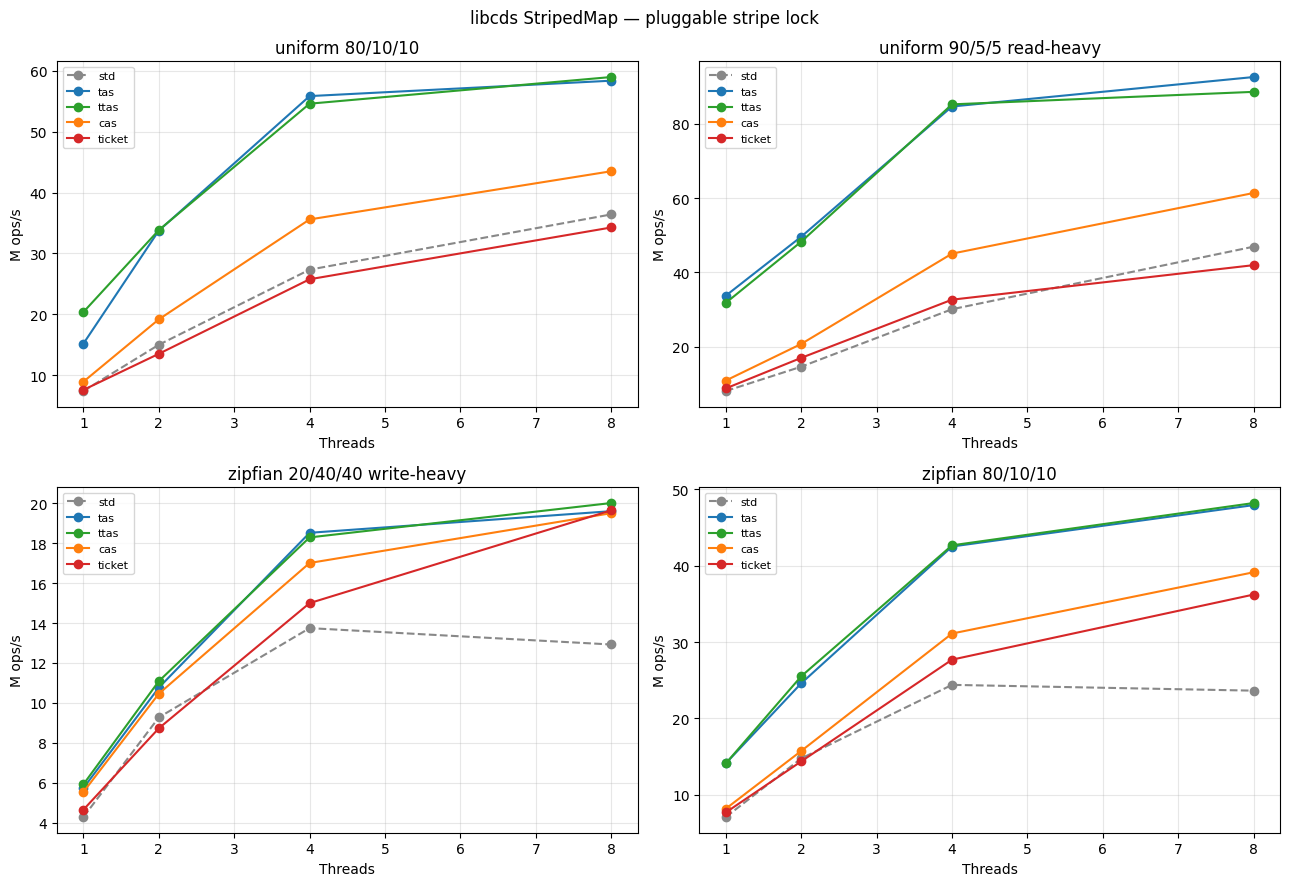

In [2]:
def plot_locks(df, title, ax_grid=(2,2), figsize=(13,9)):
    workloads = sorted(df.workload.unique())
    fig, axes = plt.subplots(*ax_grid, figsize=figsize)
    palette = {'std':'#888','tas':'tab:blue','ttas':'tab:green',
               'cas':'tab:orange','ticket':'tab:red'}
    for ax, wkl in zip(axes.flat, workloads):
        sub = df[df.workload == wkl]
        for lk in ['std','tas','ttas','cas','ticket']:
            g = sub[sub.lk == lk].sort_values('threads')
            if len(g) == 0: continue
            ls = '--' if lk == 'std' else '-'
            ax.plot(g.threads, g.ops_s/1e6, marker='o',
                    color=palette[lk], linestyle=ls, label=lk)
        ax.set_title(wkl); ax.set_xlabel('Threads'); ax.set_ylabel('M ops/s')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

plot_locks(cds, 'libcds StripedMap — pluggable stripe lock');

## Plot 2 — libcds BronsonAVLTreeMap, stripe-lock comparison

Bronson AVL uses a per-node `injecting_monitor<Lock>` (one mutex stamped onto
every tree node). Reads are optimistic — they observe a node version, walk the
child pointer without holding the lock, and re-validate the version on the way
down. So shared-read scaling is structural, not lock-derived. The lock
primitive only matters on the write path.

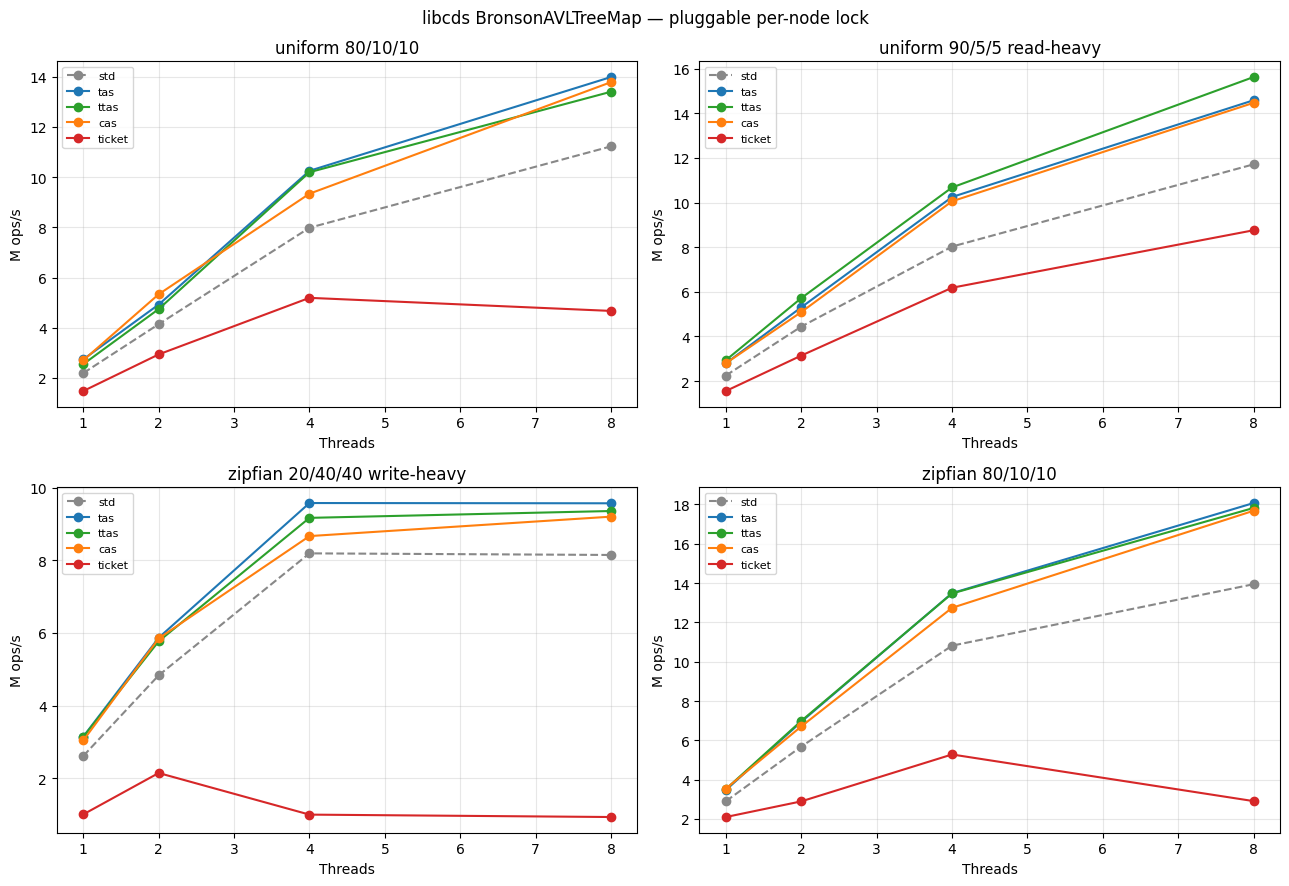

In [3]:
plot_locks(avl, 'libcds BronsonAVLTreeMap — pluggable per-node lock');

## Plot 3 — Wormhole, per-leaf-lock comparison

`default` (Wu's stock rwlock) is dashed grey, `rw` (true rwlock) is
solid grey, the rest are exclusive-only. The interesting question is:
how much does losing reader concurrency cost on a structure designed
around it?


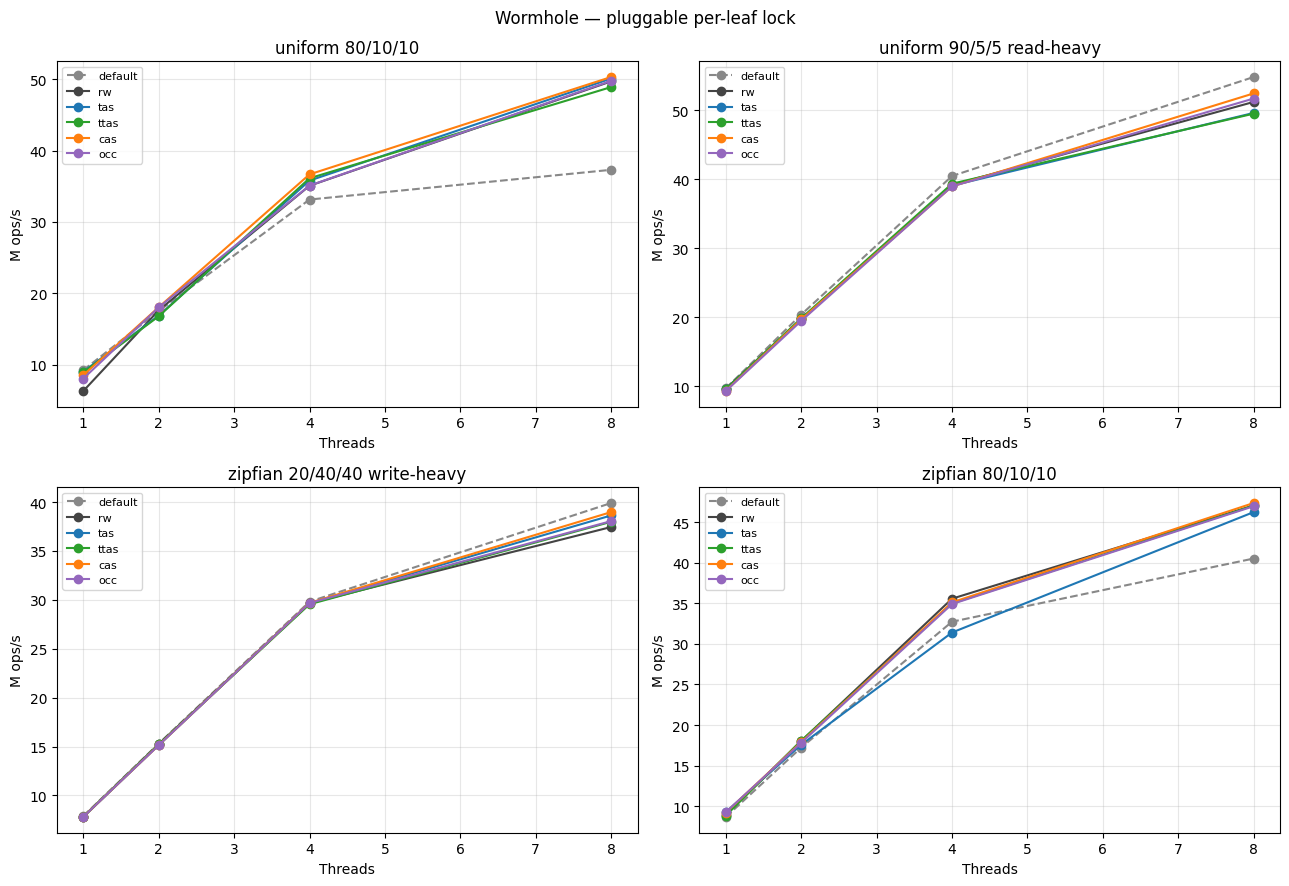

In [4]:
def plot_wh(df, title, figsize=(13,9)):
    workloads = sorted(df.workload.unique())
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    palette = {'default':'#888','rw':'#444','tas':'tab:blue',
               'ttas':'tab:green','cas':'tab:orange','occ':'tab:purple'}
    styles  = {'default':'--','rw':'-','tas':'-','ttas':'-','cas':'-','occ':'-'}
    for ax, wkl in zip(axes.flat, workloads):
        sub = df[df.workload == wkl]
        for lk in ['default','rw','tas','ttas','cas','occ']:
            g = sub[sub.lk == lk].sort_values('threads')
            if len(g) == 0: continue
            ax.plot(g.threads, g.ops_s/1e6, marker='o',
                    color=palette[lk], linestyle=styles[lk], label=lk)
        ax.set_title(wkl); ax.set_xlabel('Threads'); ax.set_ylabel('M ops/s')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

plot_wh(wh, 'Wormhole — pluggable per-leaf lock');


## Plot 4 — StripedMap vs BronsonAVL, head-to-head per lock primitive


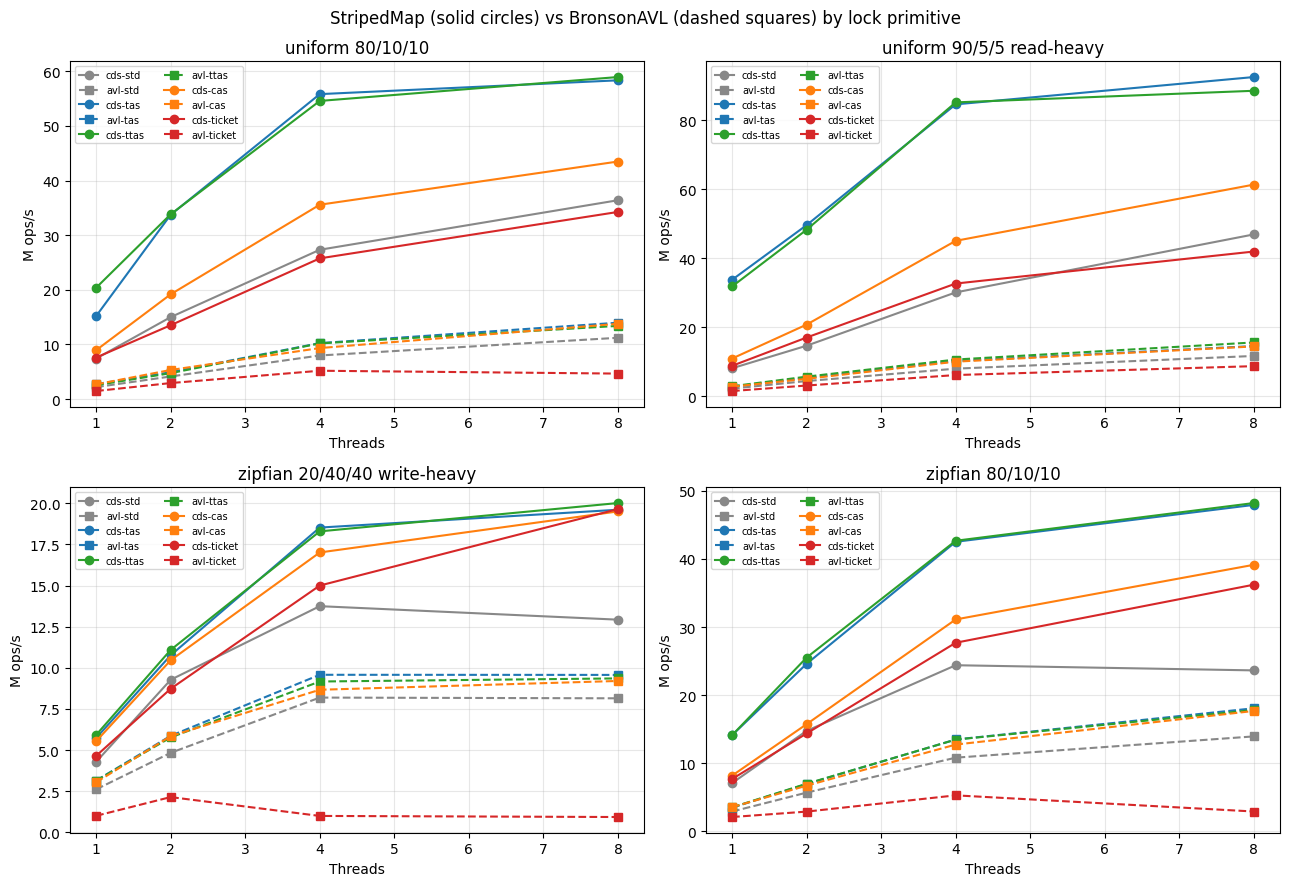

In [5]:
workloads = sorted(set(cds.workload.unique()) | set(avl.workload.unique()))
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
palette = {'std':'#888','tas':'tab:blue','ttas':'tab:green',
           'cas':'tab:orange','ticket':'tab:red'}
for ax, wkl in zip(axes.flat, workloads):
    for lk in ['std','tas','ttas','cas','ticket']:
        c = palette[lk]
        cg = cds[(cds.workload == wkl) & (cds.lk == lk)].sort_values('threads')
        ag = avl[(avl.workload == wkl) & (avl.lk == lk)].sort_values('threads')
        if len(cg): ax.plot(cg.threads, cg.ops_s/1e6, marker='o', linestyle='-',
                            color=c, label=f'cds-{lk}')
        if len(ag): ax.plot(ag.threads, ag.ops_s/1e6, marker='s', linestyle='--',
                            color=c, label=f'avl-{lk}')
    ax.set_title(wkl); ax.set_xlabel('Threads'); ax.set_ylabel('M ops/s')
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
fig.suptitle('StripedMap (solid circles) vs BronsonAVL (dashed squares) by lock primitive')
fig.tight_layout();

## 8-thread throughput table

Numerical comparison vs the `std::mutex` baseline (`std` = 1.00x for each row).

In [6]:
def at8(df, locks):
    s = df[df.threads == 8].pivot_table(index='workload', columns='lk',
                                        values='ops_s', aggfunc='mean') / 1e6
    return s[[c for c in locks if c in s.columns]]

print('=== StripedMap, 8 threads, M ops/s ===')
print(at8(cds, ['std','tas','ttas','cas','ticket']).round(1).to_string()); print()
print('=== BronsonAVL, 8 threads, M ops/s ===')
print(at8(avl, ['std','tas','ttas','cas','ticket']).round(1).to_string()); print()
print('=== Wormhole,  8 threads, M ops/s ===')
print(at8(wh,  ['default','rw','tas','ttas','cas','occ']).round(1).to_string())


=== StripedMap, 8 threads, M ops/s ===
lk                             std   tas  ttas   cas  ticket
workload                                                    
uniform 80/10/10              36.4  58.4  59.0  43.5    34.3
uniform 90/5/5 read-heavy     46.9  92.5  88.5  61.4    42.0
zipfian 20/40/40 write-heavy  12.9  19.6  20.0  19.5    19.6
zipfian 80/10/10              23.6  47.9  48.2  39.1    36.2

=== BronsonAVL, 8 threads, M ops/s ===
lk                             std   tas  ttas   cas  ticket
workload                                                    
uniform 80/10/10              11.2  14.0  13.4  13.8     4.7
uniform 90/5/5 read-heavy     11.7  14.6  15.6  14.5     8.8
zipfian 20/40/40 write-heavy   8.1   9.6   9.4   9.2     0.9
zipfian 80/10/10              13.9  18.1  17.8  17.7     2.9

=== Wormhole,  8 threads, M ops/s ===
lk                            default    rw   tas  ttas   cas   occ
workload                                                           
uniform 80/10/

In [7]:
def speedup_vs_baseline(df, locks, baseline):
    t = df[df.threads == 8].pivot_table(index='workload', columns='lk',
                                        values='ops_s', aggfunc='mean') / 1e6
    return t[[c for c in locks if c in t.columns]].div(t[baseline], axis=0).round(2)

print('=== StripedMap speedup vs cds-std (8 threads) ===')
print(speedup_vs_baseline(cds, ['std','tas','ttas','cas','ticket'], 'std').to_string())
print()
print('=== BronsonAVL speedup vs avl-std (8 threads) ===')
print(speedup_vs_baseline(avl, ['std','tas','ttas','cas','ticket'], 'std').to_string())
print()
print('=== Wormhole speedup vs wh-default (8 threads) ===')
print(speedup_vs_baseline(wh,  ['default','rw','tas','ttas','cas','occ'], 'default').to_string())


=== StripedMap speedup vs cds-std (8 threads) ===
lk                            std   tas  ttas   cas  ticket
workload                                                   
uniform 80/10/10              1.0  1.60  1.62  1.19    0.94
uniform 90/5/5 read-heavy     1.0  1.97  1.89  1.31    0.89
zipfian 20/40/40 write-heavy  1.0  1.52  1.55  1.51    1.52
zipfian 80/10/10              1.0  2.03  2.04  1.66    1.53

=== BronsonAVL speedup vs avl-std (8 threads) ===
lk                            std   tas  ttas   cas  ticket
workload                                                   
uniform 80/10/10              1.0  1.25  1.19  1.23    0.42
uniform 90/5/5 read-heavy     1.0  1.25  1.33  1.24    0.75
zipfian 20/40/40 write-heavy  1.0  1.17  1.15  1.13    0.11
zipfian 80/10/10              1.0  1.30  1.28  1.27    0.21

=== Wormhole speedup vs wh-default (8 threads) ===
lk                            default    rw   tas  ttas   cas   occ
workload                                                   

## Notes

- **`std` is the libcds default**: when libcds is used out-of-the-box without
  any traits, it ships with `std::mutex` for StripedMap stripes and
  `injecting_monitor<cds::sync::spin>` for BronsonAVL nodes (we match that
  spirit by using `std::mutex` for both, so `std` is a like-for-like baseline).
- **CPU hints used on this run**: `caffeinate -dim` to prevent App Nap and
  display sleep. Apple Silicon's scheduler places active threads on Performance
  cores by default — no explicit pinning needed (and macOS doesn't expose
  `sched_setaffinity`).
- **What makes this an apples-to-apples comparison**: both data structures
  share the bench harness, the same prefill, the same workload mixes, the
  same key range, and the same `--insert_pct == --delete_pct` symmetric mix
  so the structure size stays in steady state during measurement.
- **What's not apples-to-apples**: StripedMap is hash-based (O(1) per op);
  BronsonAVL is balanced-tree (O(log N)). The throughput gap reflects
  that algorithmic difference, *not* the lock primitive.